In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from torch import nn

### Creating a Cubic equation
* trying to fiqure out how to make a model to predict

In [2]:
# Let the equation be 3x^3+2x^2-x+5=y

x=torch.arange(-5,5,0.1).unsqueeze(dim=1)
y=3*(x**3)+2*(x**2)-x+5

x[:5],y[:5]

(tensor([[-5.0000],
         [-4.9000],
         [-4.8000],
         [-4.7000],
         [-4.6000]]),
 tensor([[-315.0000],
         [-295.0270],
         [-275.8961],
         [-257.5890],
         [-240.0880]]))

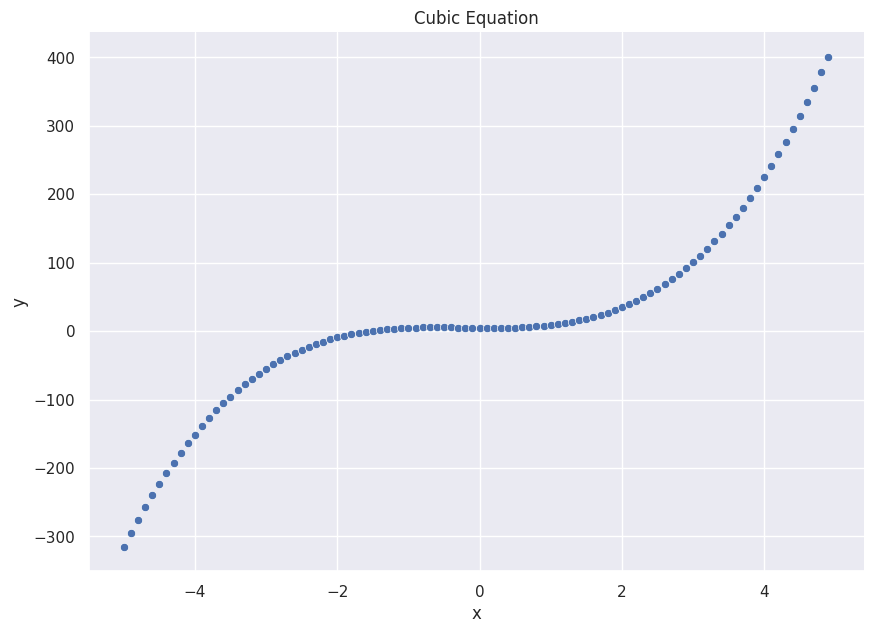

In [3]:
from seaborn.widgets import color_palette
sns.set_theme(style='darkgrid')

plt.figure(figsize=(10,7))

sns.scatterplot(x=x.squeeze(),y=y.squeeze())
plt.title('Cubic Equation')
plt.xlabel('x')
plt.ylabel('y')

sns.despine()
plt.show()

In [4]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
x_train[:5],x_test[:5]

(tensor([[ 0.5000],
         [ 3.8000],
         [-2.4000],
         [-0.8000],
         [ 1.9000]]),
 tensor([[ 3.3000],
         [ 0.3000],
         [ 2.0000],
         [-0.5000],
         [-0.6000]]))

In [6]:
y_train[:5],y_test[:5]

(tensor([[  5.3750],
         [194.6960],
         [-22.5520],
         [  5.5440],
         [ 30.8970]]),
 tensor([[131.2910],
         [  4.9610],
         [ 35.0000],
         [  5.6250],
         [  5.6720]]))

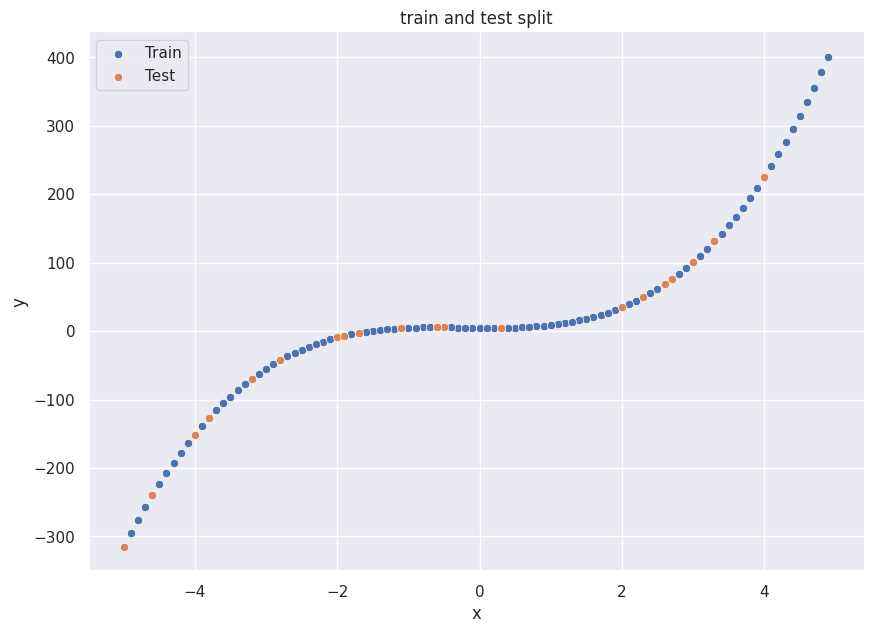

In [7]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(10,7))

sns.scatterplot(x=x_train.squeeze(),y=y_train.squeeze(),label='Train')
sns.scatterplot(x=x_test.squeeze(),y=y_test.squeeze(),label='Test')
plt.title("train and test split")

plt.xlabel('x')
plt.ylabel('y')

sns.despine()
plt.show()

In [36]:
from typing import Required
class CubicRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight1=nn.Parameter(torch.randn(1,
                             requires_grad=True,
                              dtype=torch.float))
    self.weight2=nn.Parameter(torch.randn(1,
                              requires_grad=True,
                              dtype=torch.float
                              ))
    self.weight3=nn.Parameter(torch.randn(1,
                              requires_grad=True,
                              dtype=torch.float
                              ))

    self.bias=nn.Parameter(torch.randn(1,
                           requires_grad=True,
                           dtype=torch.float
                           ))

  def forward(self,x:torch.tensor):
    return self.weight1 * (x**3) + self.weight2 * (x**2) + self.weight3 * (x) + self.bias



In [37]:
torch.manual_seed(42)

model_1=CubicRegression()

list(model_1.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True),
 Parameter containing:
 tensor([0.2303], requires_grad=True)]

In [38]:
model_1.state_dict()

OrderedDict([('weight1', tensor([0.3367])),
             ('weight2', tensor([0.1288])),
             ('weight3', tensor([0.2345])),
             ('bias', tensor([0.2303]))])

In [39]:
with torch.inference_mode():
  y_preds=model_1(x_test)

y_preds

tensor([[ 14.5064],
        [  0.3214],
        [  3.9080],
        [  0.1032],
        [  0.0633],
        [ -0.3199],
        [ -6.8073],
        [ 11.1836],
        [-20.1947],
        [-39.8080],
        [-10.2336],
        [ -2.4169],
        [  5.5475],
        [ -1.4502],
        [ 24.7773],
        [-30.8947],
        [  7.6284],
        [  8.4295],
        [-17.2755],
        [ -2.0595]])